<a href="https://colab.research.google.com/github/jelitazalukhu/Responsi-AI-Optimalisasi-Data/blob/main/animal_classifier_JelitaCrisnaZalukhu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jeliichan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:17<00:00, 41.1MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].value_counts())
data_df.head()

labels
cat     5653
dog     5239
wild    5238
Name: count, dtype: int64


,image_path,labels
0,/content/animal-faces/afhq/train/dog/flickr_do...,dog
1,/content/animal-faces/afhq/train/dog/flickr_do...,dog
2,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
3,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
4,/content/animal-faces/afhq/train/dog/flickr_do...,dog


In [4]:
from sklearn.model_selection import train_test_split
train, temp = train_test_split(
    data_df,
    test_size=0.3,
    stratify=data_df["labels"],
    random_state=42
)
val, test = train_test_split(
    temp,
    test_size=0.5,
    stratify=temp["labels"],
    random_state=42
)
print(train.shape, test.shape, val.shape)

(11291, 2) (2420, 2) (2419, 2)


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

LabelEncoder()

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [7]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, label_encoder, transform=None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels']))

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)

    return image, label

In [8]:
train_dataset = CustomImageDataset(dataframe=train, label_encoder=label_encoder, transform=train_transform)
test_dataset = CustomImageDataset(dataframe=test, label_encoder=label_encoder, transform=val_test_transform)
val_dataset = CustomImageDataset(dataframe=val, label_encoder=label_encoder, transform=val_test_transform)

In [9]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/dog/pixabay_dog_002077.jpg


In [10]:
train_dataset.__getitem__(2)

(tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 tensor(1))

In [11]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

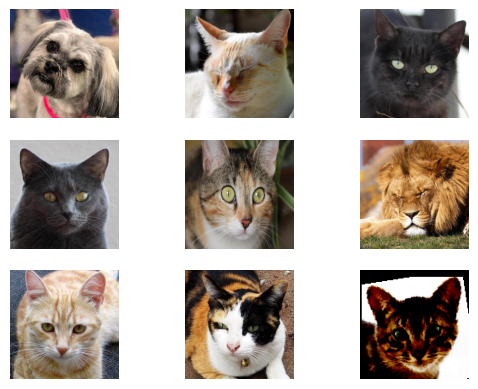

In [12]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

image, label = train_dataset[np.random.randint(0, len(train_dataset))]
plt.imshow(image.permute(1,2,0))
plt.axis('off')

In [13]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 20

In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pooling = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.flatten = nn.Flatten()
        self.linear = nn.Linear(128 * 16 * 16, 128)
        self.output = nn.Linear(128, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.pooling(self.relu(self.bn1(self.conv1(x))))
        x = self.pooling(self.relu(self.bn2(self.conv2(x))))
        x = self.pooling(self.relu(self.bn3(self.conv3(x))))

        x = self.flatten(x)
        x = self.relu(self.linear(x))
        x = self.dropout(x)
        x = self.output(x)

        return x

In [16]:
model = Net().to(device)

In [17]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
           Linear-14                  [

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [19]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    model.train()
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        total_loss_train += train_loss.item()

        _, preds = torch.max(outputs, 1)
        total_acc_train += (preds == labels).sum().item()

    model.eval()
    total_loss_val = 0
    total_acc_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            val_loss = criterion(outputs, labels)

            total_loss_val += val_loss.item()

            _, preds = torch.max(outputs, 1)
            total_acc_val += (preds == labels).sum().item()

    avg_train_loss = total_loss_train / len(train_loader)
    avg_val_loss = total_loss_val / len(val_loader)

    train_accuracy = (total_acc_train / len(train_dataset)) * 100
    val_accuracy = (total_acc_val / len(val_dataset)) * 100

    total_loss_train_plot.append(avg_train_loss)
    total_loss_validation_plot.append(avg_val_loss)
    total_acc_train_plot.append(train_accuracy)
    total_acc_validation_plot.append(val_accuracy)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    print("-"*50)

Epoch 1/20
Train Loss: 0.6846 | Train Acc: 70.35%
Val Loss: 0.2444 | Val Acc: 91.69%
--------------------------------------------------
Epoch 2/20
Train Loss: 0.4011 | Train Acc: 84.13%
Val Loss: 0.1697 | Val Acc: 93.39%
--------------------------------------------------
Epoch 3/20
Train Loss: 0.3200 | Train Acc: 87.79%
Val Loss: 0.1392 | Val Acc: 94.87%
--------------------------------------------------
Epoch 4/20
Train Loss: 0.2790 | Train Acc: 89.89%
Val Loss: 0.1055 | Val Acc: 96.32%
--------------------------------------------------
Epoch 5/20
Train Loss: 0.2623 | Train Acc: 90.44%
Val Loss: 0.1022 | Val Acc: 96.69%
--------------------------------------------------
Epoch 6/20
Train Loss: 0.2362 | Train Acc: 91.22%
Val Loss: 0.0937 | Val Acc: 96.53%
--------------------------------------------------
Epoch 7/20
Train Loss: 0.2290 | Train Acc: 91.23%
Val Loss: 0.0826 | Val Acc: 96.78%
--------------------------------------------------
Epoch 8/20
Train Loss: 0.2238 | Train Acc: 91.61

In [20]:
model.eval()
total_loss_test = 0
total_acc_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        predictions = model(inputs)

        test_loss = criterion(predictions, labels)
        total_loss_test += test_loss.item()

        _, preds = torch.max(predictions, 1)
        total_acc_test += (preds == labels).sum().item()

avg_test_loss = total_loss_test / len(test_loader)
test_accuracy = (total_acc_test / len(test_dataset)) * 100
print(f"Test Accuracy: {test_accuracy:.2f}% | Test Loss: {avg_test_loss:.4f}")

Test Accuracy: 97.77% | Test Loss: 0.0735


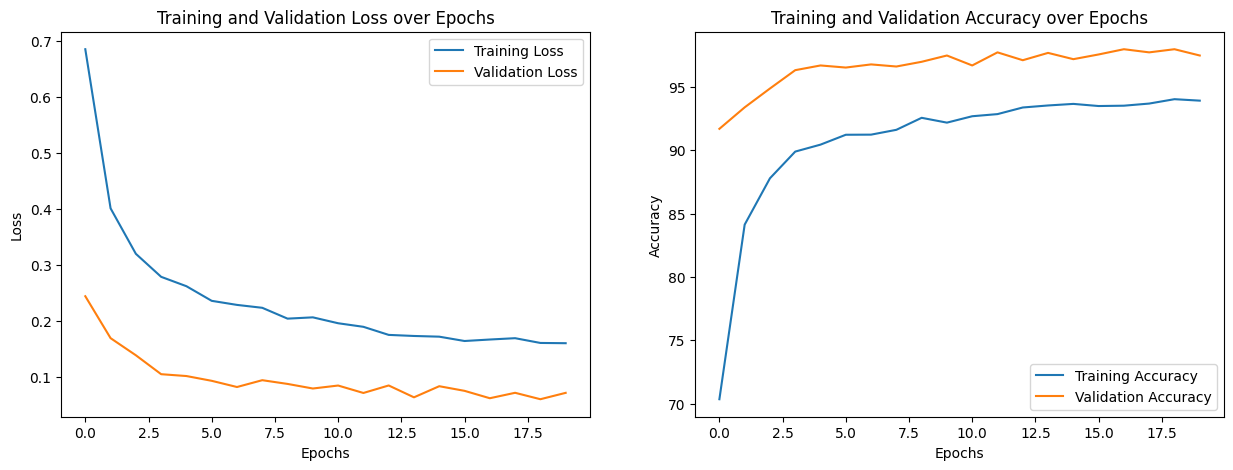

In [21]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

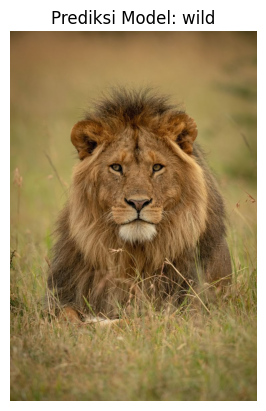

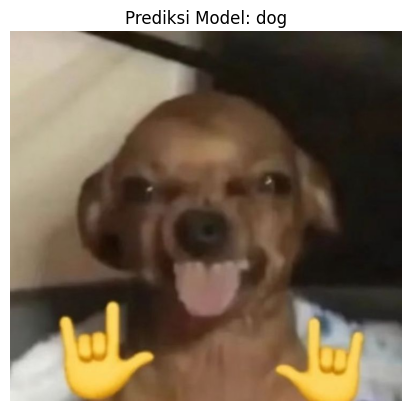

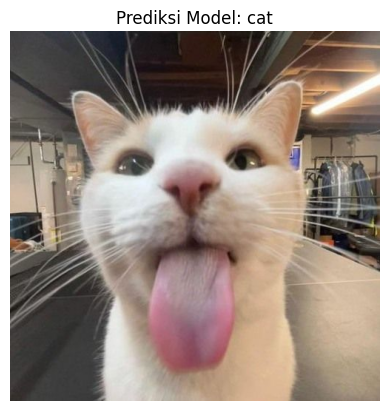

cat


In [22]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path):
    if 'model' not in globals():
        return "Error: Variabel 'model' belum ada. Jalankan dulu sel arsitektur & Net()."

    global transform
    if 'transform' not in globals():
        import torchvision.transforms as transforms
        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    model.eval()

    try:

        image_raw = Image.open(image_path).convert('RGB')
        image_tensor = transform(image_raw).to(device)

        with torch.no_grad():
            output = model(image_tensor.unsqueeze(0))
            index = torch.argmax(output, axis=1).item()

        label = label_encoder.inverse_transform([index])[0]

        plt.imshow(image_raw)
        plt.title(f"Prediksi Model: {label}")
        plt.axis('off')
        plt.show()

        return label

    except FileNotFoundError:
        return f"Error: File '{image_path}' tidak ditemukan di folder /content/"
    except Exception as e:
        return f"Error lainnya: {e}"

hasil = predict_image("/content/raja hutan.jpg")
hasil = predict_image("/content/anjing.jpg")
hasil = predict_image("/content/kucing.jpg")
print(hasil)

In [23]:
import torch

torch.save(model.state_dict(), 'animal_classifier.pth')

from google.colab import files
files.download('animal_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>